# Exploratory analysis: dental care utilization

This notebook documents the exploration that shaped the modelling
choices in `src/train.py`. It answers three questions:

1. Is the target balanced enough for AUC-ROC to be meaningful?
2. Which variables actually separate users from non-users?
3. Is the relationship linear enough to expect a logistic regression
   to hold its own against gradient boosting?

The dataset is synthetic and seeded. It is generated by
`src/data_pipeline.py`, which draws the target from a logistic model
over the features, so the ground truth is known. That makes this a
sanity check on the pipeline as much as an exploration.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

from features import load_and_prepare  # noqa: E402

sns.set_theme(style='whitegrid')
pd.set_option('display.width', 120)

df = load_and_prepare(ROOT / 'data' / 'dental_claims.csv')
print(f'{len(df):,} rows, {df.shape[1]} columns')
df.head()

50,000 rows, 13 columns


,age,gender,income_bracket,region,has_complementary_insurance,dental_visits_3y,claim_amount,treatment_type,distance_to_provider_km,prev_utilization_rate,days_since_last_visit,nb_dependents,utilized
0,23,M,high,rural,1,3,1660.64,orthodontic,1.0,0.419,682,3,1
1,69,F,medium,rural,1,2,1210.56,preventive,11.4,0.751,906,2,0
2,61,F,medium,suburban,1,4,1255.87,restorative,15.0,0.558,446,0,1
3,47,F,low,urban,1,5,881.51,prosthetic,4.8,0.411,1795,1,0
4,47,M,medium,suburban,1,1,850.57,restorative,5.3,0.674,867,1,1


## 1. Target balance and data quality

In [2]:
rate = df['utilized'].mean()
print(f'Utilization rate: {rate:.1%}')
print(f'Missing values: {int(df.isna().sum().sum())}')
print(f'Duplicate rows: {int(df.duplicated().sum())}')
df.describe().T[['mean', 'std', 'min', '50%', 'max']].round(2)

Utilization rate: 61.7%
Missing values: 0
Duplicate rows: 0


,mean,std,min,50%,max
age,50.96,19.36,18.00,51.00,84.00
has_complementary_insurance,0.75,0.43,0.00,1.00,1.00
dental_visits_3y,2.50,1.58,0.00,2.00,14.00
claim_amount,1023.06,562.02,50.01,1020.16,1999.97
distance_to_provider_km,8.02,8.02,0.00,5.60,89.30
prev_utilization_rate,0.60,0.20,0.01,0.62,1.00
days_since_last_visit,366.38,366.18,0.00,254.00,3199.00
nb_dependents,1.21,1.10,0.00,1.00,8.00
utilized,0.62,0.49,0.00,1.00,1.00


The positive class sits near 62%. That is mildly imbalanced, enough to
make raw accuracy a poor headline metric (a constant 'will use'
prediction already scores 62%) but not enough to need resampling.
Both reasons AUC-ROC is the metric reported in the README, and why the
models use `class_weight='balanced'`.

## 2. Which numeric variables separate the two groups?

In [3]:
numeric = df.select_dtypes(include='number').drop(columns=['utilized'])

rows = []
for col in numeric.columns:
    used = df.loc[df['utilized'] == 1, col]
    not_used = df.loc[df['utilized'] == 0, col]
    t_stat, p_value = stats.ttest_ind(used, not_used, equal_var=False)
    pooled = np.sqrt((used.var() + not_used.var()) / 2)
    rows.append({
        'feature': col,
        'mean_used': used.mean(),
        'mean_not_used': not_used.mean(),
        "cohen_d": (used.mean() - not_used.mean()) / pooled,
        'p_value': p_value,
    })

separation = (pd.DataFrame(rows)
              .assign(abs_d=lambda d: d['cohen_d'].abs())
              .sort_values('abs_d', ascending=False)
              .drop(columns='abs_d')
              .round(4))
separation

,feature,mean_used,mean_not_used,cohen_d,p_value
0,age,53.4553,46.9408,0.3415,0.0
6,days_since_last_visit,322.6786,436.8525,-0.3051,0.0
1,has_complementary_insurance,0.7971,0.6666,0.2979,0.0
3,claim_amount,970.4787,1107.8376,-0.2464,0.0
2,dental_visits_3y,2.6234,2.2932,0.2111,0.0
4,distance_to_provider_km,7.3879,9.0380,-0.2021,0.0
5,prev_utilization_rate,0.6147,0.5763,0.1927,0.0
7,nb_dependents,1.2448,1.1422,0.0938,0.0


Effect sizes are small to moderate. No single variable dominates, which
is why the ceiling on AUC sits near 0.71 rather than 0.9: the signal is
spread thinly across many weak predictors, exactly as the generating
process was written.

## 3. Utilization by segment

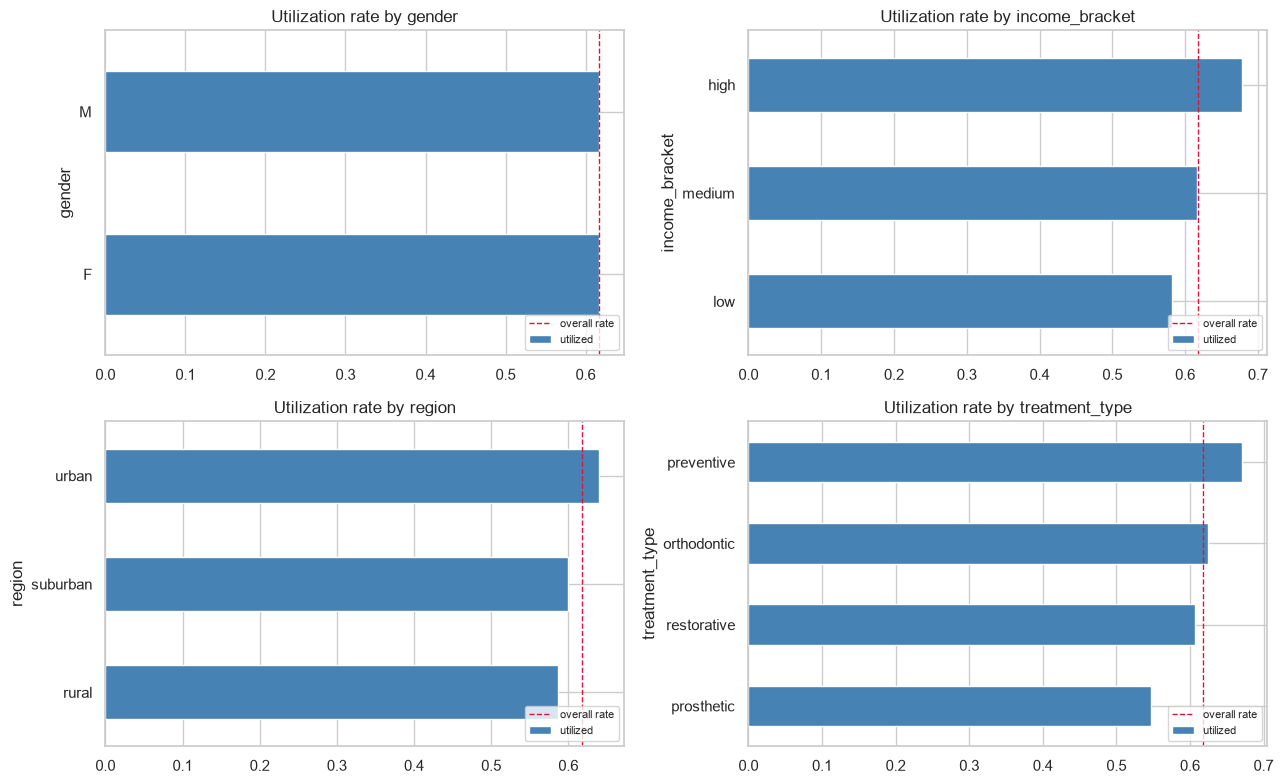

In [4]:
categorical = ['gender', 'income_bracket', 'region', 'treatment_type']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, col in zip(axes.ravel(), categorical):
    segment = df.groupby(col, observed=True)['utilized'].mean().sort_values()
    segment.plot(kind='barh', ax=ax, color='steelblue')
    ax.axvline(df['utilized'].mean(), color='crimson', ls='--', lw=1,
               label='overall rate')
    ax.set_title(f'Utilization rate by {col}')
    ax.set_xlabel('')
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
for col in categorical:
    table = pd.crosstab(df[col], df['utilized'])
    chi2, p_value, _, _ = stats.chi2_contingency(table)
    verdict = 'associated' if p_value < 0.01 else 'no evidence'
    print(f'{col:>16}  chi2={chi2:8.2f}  p={p_value:.2e}  {verdict}')

          gender  chi2=    0.00  p=9.92e-01  no evidence
  income_bracket  chi2=  249.34  p=7.18e-55  associated
          region  chi2=  117.87  p=2.54e-26  associated
  treatment_type  chi2=  399.00  p=3.64e-86  associated


`treatment_type` and `income_bracket` shift the rate measurably;
`gender` does not, and the chi-squared test agrees. Gender is kept in
the model anyway: it costs nothing and its coefficient lands near zero,
which is itself a useful check that the pipeline is not inventing
signal.

## 4. Is the relationship linear in the log-odds?

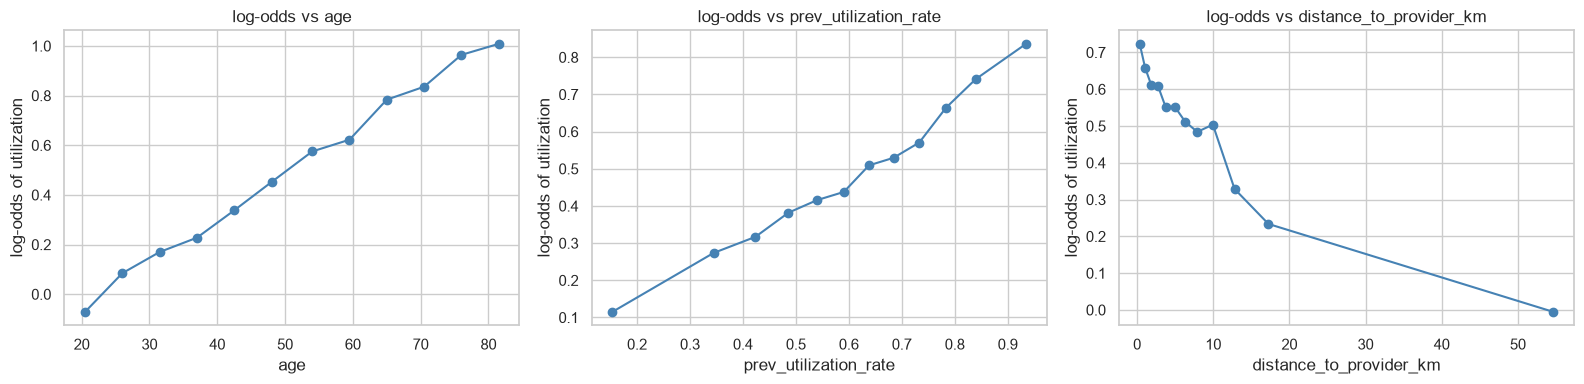

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['age', 'prev_utilization_rate',
                          'distance_to_provider_km']):
    binned = pd.qcut(df[col], q=12, duplicates='drop')
    grouped = df.groupby(binned, observed=True)['utilized'].mean()
    centres = [interval.mid for interval in grouped.index]
    odds = grouped / (1 - grouped)
    ax.plot(centres, np.log(odds), 'o-', color='steelblue')
    ax.set_title(f'log-odds vs {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('log-odds of utilization')

plt.tight_layout()
plt.show()

The log-odds move close to linearly with each predictor. That is the
single most useful finding in this notebook: it predicts that a
logistic regression will match or beat tree ensembles here, which is
what the benchmark then shows (AUC 0.713 against 0.706 and 0.705).

It is also a reminder about synthetic data. The target was drawn from a
logistic model, so linearity is built in. On real claims data the same
plot would almost certainly bend, and the ranking of the three models
could reverse. The benchmark result belongs to this dataset, not to the
problem in general.

## 5. Correlation structure

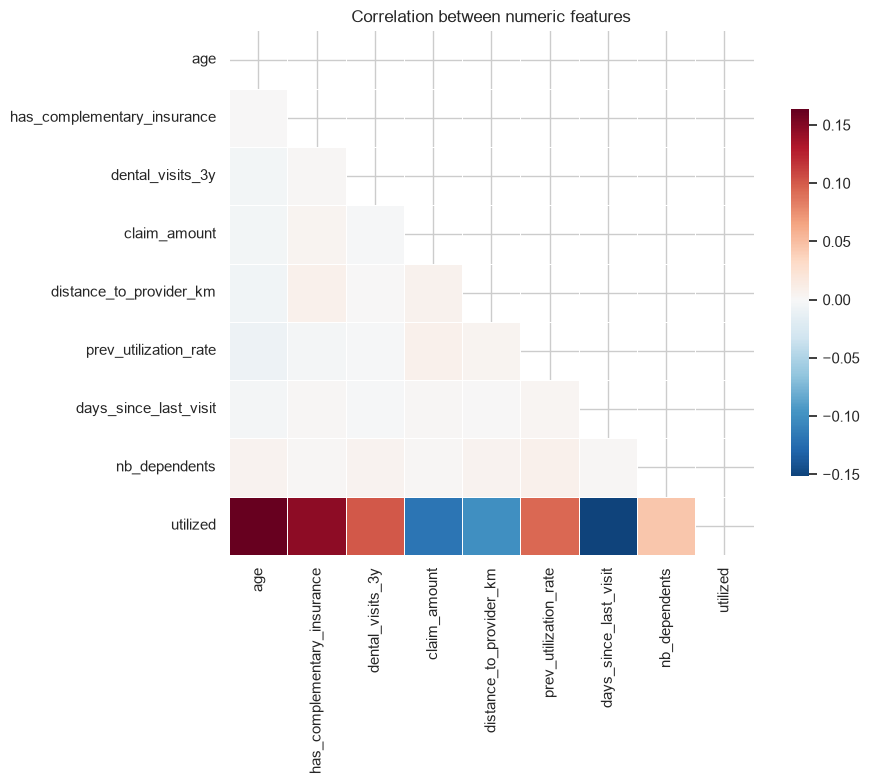

Strongest correlations with the target:
age                            0.164
days_since_last_visit          0.152
has_complementary_insurance    0.146
claim_amount                   0.119
dental_visits_3y               0.101
distance_to_provider_km        0.100
Name: utilized, dtype: float64


In [7]:
corr = df.select_dtypes(include='number').corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=False,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Correlation between numeric features')
plt.tight_layout()
plt.show()

print('Strongest correlations with the target:')
print(corr['utilized'].drop('utilized').abs().sort_values(ascending=False).head(6).round(3))

No pair of predictors is strongly collinear, so the logistic
coefficients can be read individually without a variance inflation
check turning up anything alarming.

### What this means for modelling

- AUC-ROC is the right headline metric given the 62/38 split.
- The signal is weak and spread out, so an AUC near 0.71 is the
  realistic ceiling rather than a sign of an underfit model.
- The log-odds are close to linear, so a regularised linear model is a
  strong baseline and the one the benchmark ends up selecting.
- `high_claim` is derived from a quantile, which has to be fitted on
  the training split alone. That is handled in
  `features.fit_feature_config` and covered by a test.